In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [5]:
indices = [i for i in range(12)]
num_datasets = [i for i in range(2, 9)]
dataset_names = ["DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "Stanford_Cars", "SUN397", "SVHN"]
domain = "Base_Fine_Tuned"

In [15]:
results = {i: [] for i in num_datasets}
task_matrix = {}

for i in num_datasets:
    data_path = f"../Data/Multi_Class_Augmentation/{i}_{domain}/Entire_Transformation_Matrix_W"

    try:
        for filename in os.listdir(data_path):
            if filename == ".DS_Store":
                continue
            if filename in ["Task_Matrix_W.json"]:
                file_path = os.path.join(f"{data_path}", filename)
                if os.path.isfile(file_path):
                    task_matrix[i] = file_path
                continue
            file_path = os.path.join(f"{data_path}", filename)
            if os.path.isfile(file_path):
                results[i].append(file_path)
    except FileNotFoundError:
        print(f"Error: The Folder '{data_path}' was not found.")
    except Exception as e:
        print(f"An error occured: {e}")

for i in results:
    results[i].sort(key=lambda s: s.lower())

In [16]:
datasets = {i: [] for i in num_datasets}
task_matrixes = []

for i in num_datasets:
    task_matrixes.append(pd.read_json(task_matrix[i]))
    for j in results[i]:
        datasets[i].append(pd.read_json(j))

In [17]:
print(len(datasets[8]))

8


In [ ]:
# datasets: num_datasets, type of dataset. Both DTD (2) and EuroSAT (3) have the same number of data pieces

In [28]:
accuracy = {i: [] for i in range(len(num_datasets)+1)}

print(len(accuracy))

8


In [36]:
accuracy = {i: [] for i in range(len(dataset_names))}

for dataset in num_datasets:
    for loop in num_datasets[0:dataset]:
        accuracy[loop-2].append(datasets[dataset][loop-2]["Classification_Accuracy"])
    if dataset == num_datasets[-1]:
        accuracy[len(accuracy)-1].append(datasets[dataset][-1]["Classification_Accuracy"])

In [38]:
# accuracy = {i: [] for i in num_datasets}

# for dataset in num_datasets:
#     for loop in num_datasets[0:dataset]:
#         accuracy[loop].append(datasets[dataset][loop-2]["Classification_Accuracy"])

In [43]:
singular_matrixes = [0.7622340425531915, 0.9581481481481482, 0.8439429928741092, 0.9224, 0.9025396825396825, 0.7972888944161174, 0.7441309823677582, 0.6391364474492932]
fine_tuned = [0.7851,0.9859,0.9811,0.9946,0.9343,0.8314,0.7391, 0.9662]
linear_probe = [0.7675531914893617,0.9566666666666667,0.8654790182106097, 0.9878,0.913968253968254,0.79791070762343,0.7385390428211587, 0.6546173939766441]

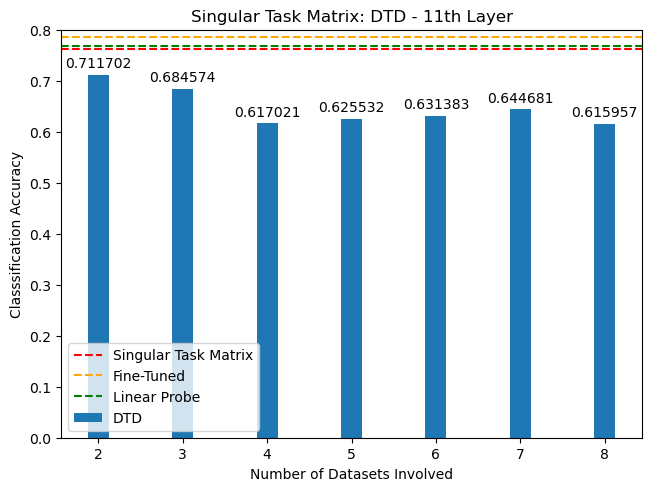

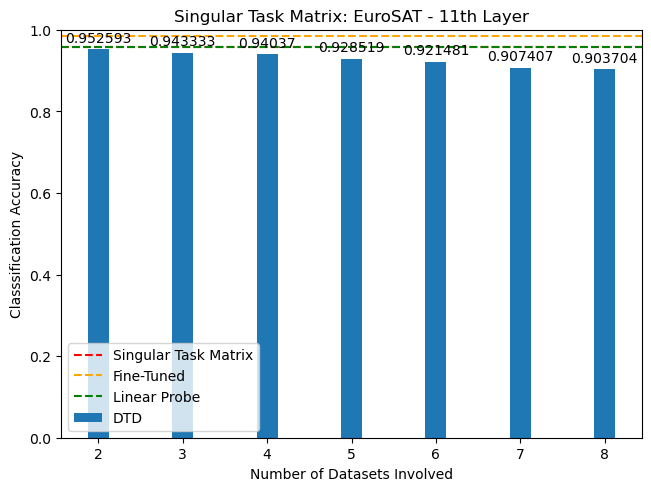

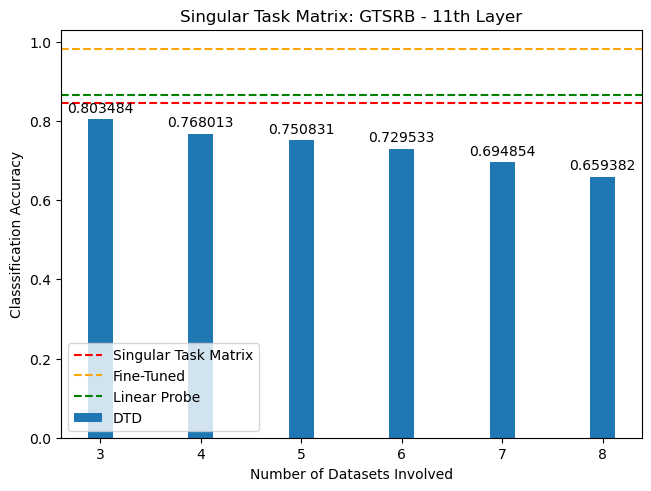

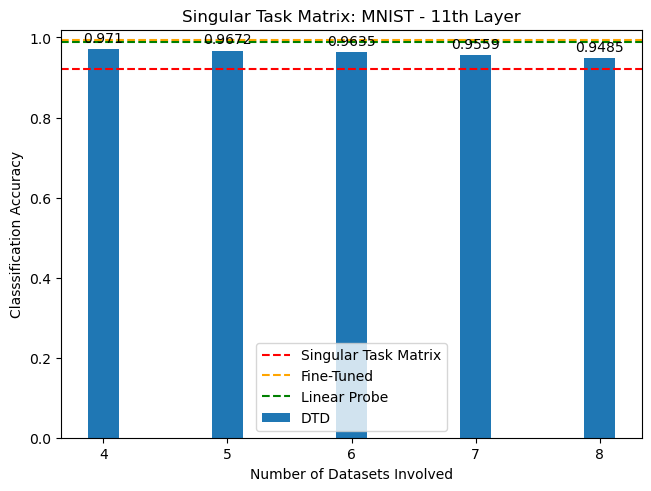

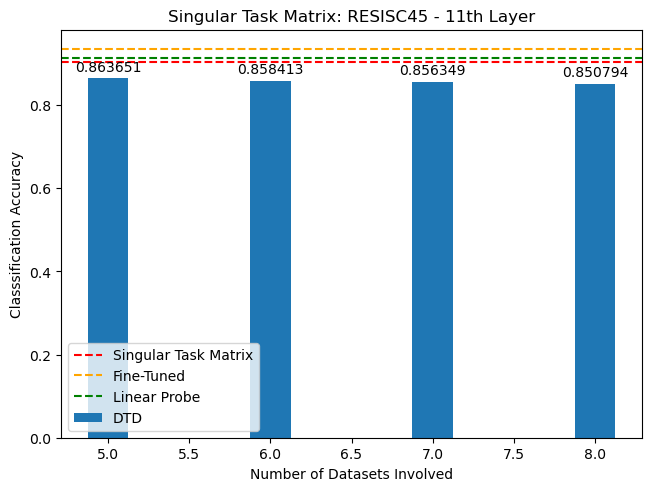

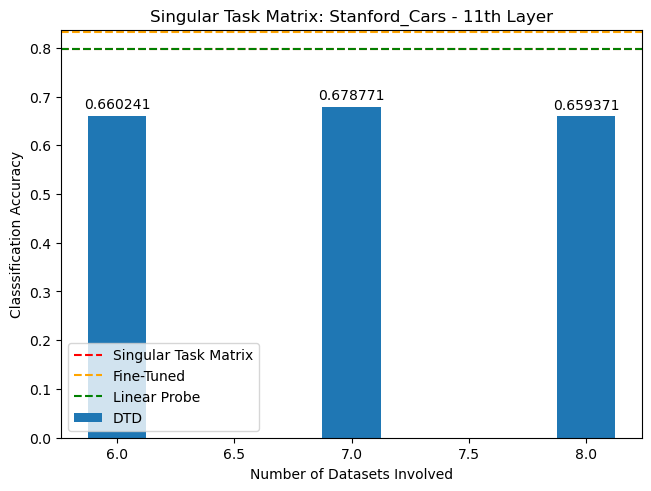

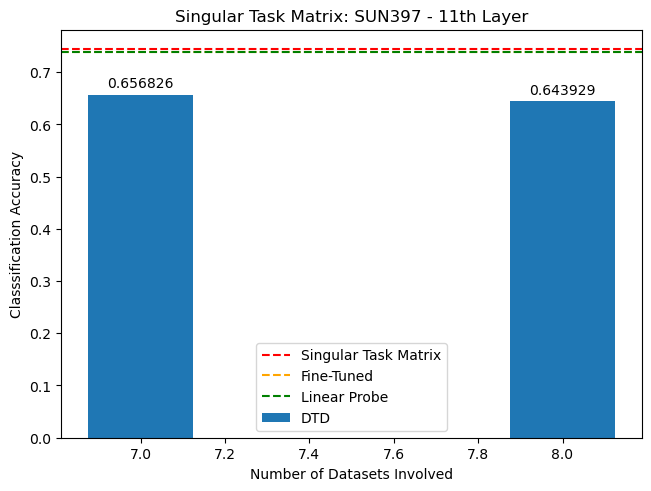

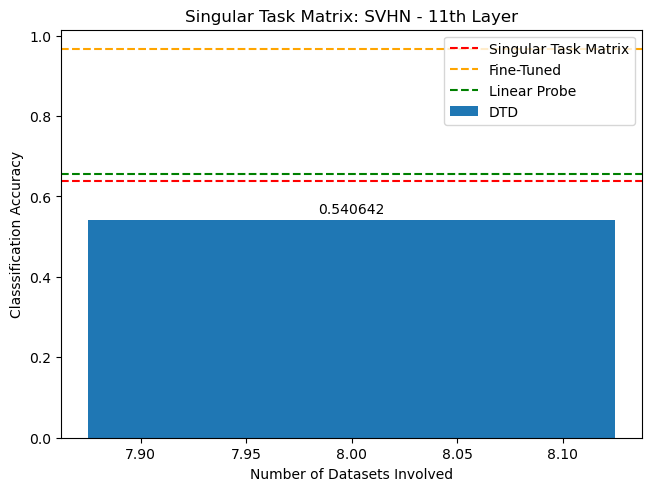

In [50]:
incrementer = 2
num_data = 7

for i in range(len(dataset_names)):
    test_acc = []
    for j in range(num_data):
        test_acc.append(accuracy[i][j][11])

    x = np.arange(incrementer, 9)
    width = 0.25
    multiplier = 0

    fix, ax = plt.subplots(layout="constrained")

    offset = width * multiplier
    rects = ax.bar(x+offset, test_acc, width, label="DTD")
    ax.bar_label(rects, padding=3)
    multiplier += 1

    plt.axhline(y=singular_matrixes[i], color='red', linestyle="--", label="Singular Task Matrix")
    plt.axhline(y=fine_tuned[i], color='orange', linestyle="--", label="Fine-Tuned")
    plt.axhline(y=linear_probe[i], color='green', linestyle="--", label="Linear Probe")

    ax.set_ylabel("Classsification Accuracy")
    ax.set_xlabel("Number of Datasets Involved")
    ax.set_title(f"Singular Task Matrix: {dataset_names[i]} - 11th Layer")
    ax.legend()
    plt.savefig(f"../Multi_Class_Augmentation_Graphs/Singular_Task_Matrix_{dataset_names[i]}", dpi=600)
    plt.show()

    if i != 0:
        incrementer += 1
        num_data -= 1